<a href="https://colab.research.google.com/github/NVHau-K14/Tuan04_ThucHanh_DeepLearning/blob/main/CNN_NhanDangChoMeo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow-datasets

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.callbacks import EarlyStopping

dataset, info = tfds.load(
    "cats_vs_dogs",
    with_info=True,
    as_supervised=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.LTQXT8_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "cats_vs_dogs",
    with_info=True,
    as_supervised=True
)

In [ ]:
all_data = dataset["train"]

dataset_size = info.splits["train"].num_examples

train_size = int(dataset_size * 0.8)

train_ds = all_data.take(train_size)
val_ds = all_data.skip(train_size)

print("Train:", train_size)
print("Validation:", dataset_size - train_size)

Train: 18609
Validation: 4653


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess(image, label):

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

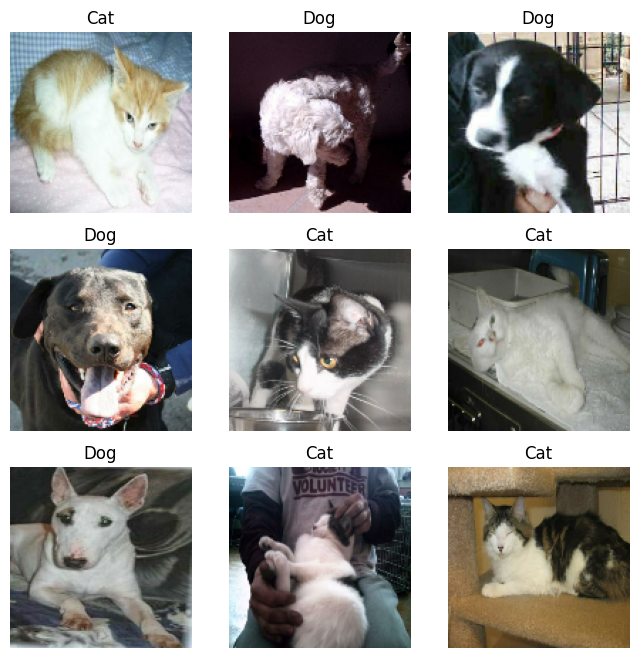

In [ ]:
class_names = ["Cat", "Dog"]

plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [ ]:
model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        256,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        512,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation='sigmoid'
    )

])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,108,033 (19.49 MB)

 Trainable params: 5,108,033 (19.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 75s 115ms/step - accuracy: 0.6035 - loss: 0.6533 - val_accuracy: 0.7159 - val_loss: 0.5708
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.7299 - loss: 0.5352 - val_accuracy: 0.7920 - val_loss: 0.4368
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.8086 - loss: 0.4228 - val_accuracy: 0.8261 - val_loss: 0.3884
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 80s 70ms/step - accuracy: 0.8487 - loss: 0.3398 - val_accuracy: 0.8405 - val_loss: 0.3568
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 73ms/step - accuracy: 0.8819 - loss: 0.2725 - val_accuracy: 0.8764 - val_loss: 0.2884
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.9112 - loss: 0.2148 - val_accuracy: 0.8706 - val_loss: 0.3212
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.9337 - loss: 0.1667 - val_accuracy: 0.8874 - val_loss: 0.2864
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9445 - loss: 0.1372 -

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

Saving images1.jpg to images1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


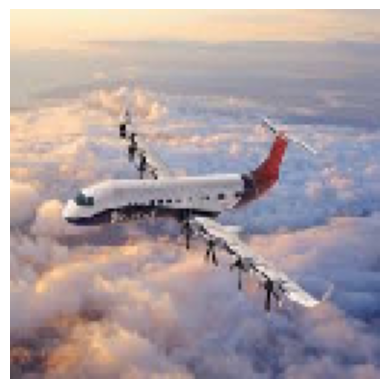

Score: 0.011383529
🐱 CAT


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = image.load_img(
    filename,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis("off")
plt.show()

print("Score:", prediction)

if prediction > 0.5:
    print("🐶 DOG")
else:
    print("🐱 CAT")